<a href="https://colab.research.google.com/github/sanjay-sj87/deep-learning/blob/main/11MTCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
import zipfile
import os

zip_file_path = "/actors.zip"

extract_dir = "."

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(os.path.abspath(extract_dir))

/content


In [11]:
from google.colab import drive
drive.mount('/actors')

Mounted at /actors


In [14]:
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.9 MB/s eta 0:00:00


In [15]:
import cv2
from mtcnn.mtcnn import MTCNN

In [16]:
detector = MTCNN()

In [17]:
image = cv2.imread("actors/11.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [18]:
result = detector.detect_faces(image_rgb)

In [19]:
for face in result:
  x, y, w, h = face['box']
  cv2.rectangle(image_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)

(np.float64(-0.5), np.float64(671.5), np.float64(719.5), np.float64(-0.5))

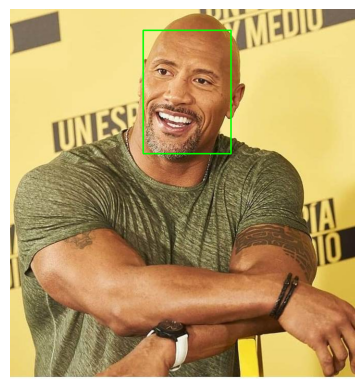

In [20]:
plt.imshow(image_rgb)
plt.axis('off')

Found 1 face(s).


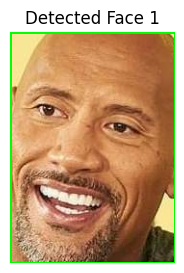

In [21]:
if result:
    print(f"Found {len(result)} face(s).")
    for i, face in enumerate(result):
        x, y, w, h = face['box']
        cropped_face = image_rgb[y:y+h, x:x+w]

        plt.figure(figsize=(3, 3))
        plt.imshow(cropped_face)
        plt.title(f'Detected Face {i+1}')
        plt.axis('off')
        plt.show()
else:
    print("No faces detected in the image.")